# Testing FASTT-Alternating DiagonalGating

This notebook provides an interactive environment to test the feature selection capabilities of `FASTTAlternating` using the `diagonal` transform paired with a non-differentiable `AdaSTTXGBoost` selector. 

Because this notebook is renderable by our CCDS documentation generators (such as `mkdocs-jupyter`, `Sphinx`, or `Quarto`), we can include rich outputs and visualizations directly alongside our documentation.

In [1]:
import os
import sys

# Ensure the project root is on the path
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import mlflow

from s2t_fs.data.synthetic import generate_synthetic_data
from s2t_fs.models.fastt.fastt_alternating import FASTTAlternating
from s2t_fs.models.adastt_xgboost import AdaSTTXGBoost
from s2t_fs.utils.logger import custom_logger as logger

## 1. Synthetic Data Generation

We generate a synthetic dataset with exactly **5 informative** features and **25 noise** features. Our goal is to ensure the alternating gradient strategy learns to ignore the 25 noisy features while assigning high importance to the informative ones.

In [2]:
data_params = {
    "n_samples": 4000,
    "n_informative": 5,
    "n_noise": 25,
    "n_experts": 3,
    "test_size": 0.2,
    "seed": 0
}

X_train, Y_train, X_test, Y_test, stats = generate_synthetic_data(data_params)
print(f"Data generated: {stats['num_total_rows']} rows, {stats['num_features']} total features")

Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3908


Data generated: 4000 rows, 30 total features


## 2. Model Training

We instantiate an `AdaSTTXGBoost` classifier and pass it to the `FASTTAlternating` algorithm. Over `num_iterations=5` alternating rounds, the algorithm will iteratively fit the XGBoost selector on transformed features, construct a linear surrogate objective mapping inputs to the leaf probability output space, and gradient descent the `diagonal` transformation weights.

In [3]:
base_selector = AdaSTTXGBoost(n_estimators=50, learning_rate=0.1, max_depth=4, early_stopping_rounds=10)

model = FASTTAlternating(
    base_selector=base_selector,
    transform_type="diagonal",
    transform_kwargs={"lambda1": 0.05, "lambda2": 0.01},
    num_iterations=20,
    transform_lr=1e-2,
    transform_steps=200,
    random_state=42
)

model.fit(X_train, Y_train)

,base_selector,AdaSTTXGBoost...estimators=50)
,transform_type,'diagonal'
,transform_kwargs,"{'lambda1': 0.05, 'lambda2': 0.01}"
,num_iterations,20
,transform_lr,0.01
,transform_steps,200
,random_state,42
,n_estimators,50
,learning_rate,0.1
,max_depth,4
,subsample,0.8


## 3. Visualization of Alternating Gating Weights

Because the alternating algorithm uses a global wrapper transform (rather than nested routing boosts), `model.get_gating_weights()` extracts a single 1D vector detailing the holistic dimension importance mapping.

We should observe distinct magnitude spikes for the first 5 features (informative) and a flat baseline near zero for the remaining 25 features.

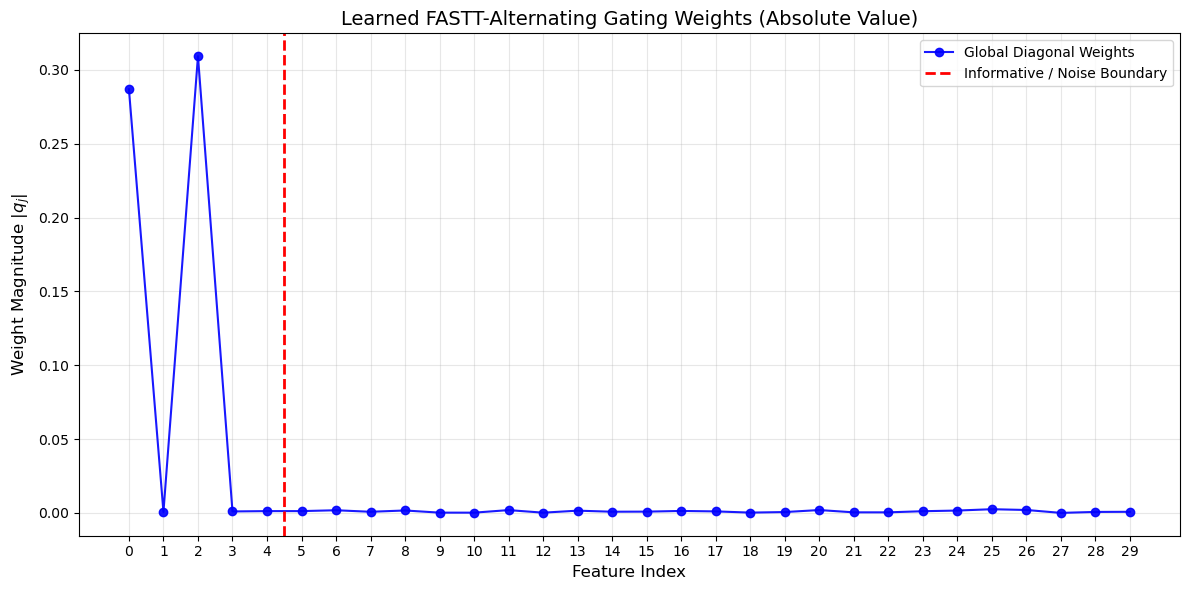

In [4]:
gating_weights = model.get_gating_weights()

plt.figure(figsize=(12, 6))
plt.plot(np.abs(gating_weights), marker='o', alpha=0.9, color='blue', label='Global Diagonal Weights')
    
plt.axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='Informative / Noise Boundary')
plt.title('Learned FASTT-Alternating Gating Weights (Absolute Value)', fontsize=14)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Weight Magnitude $|q_j|$', fontsize=12)
plt.xticks(range(30))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
gating_weights

array([-2.8689542e-01,  6.5439864e-04,  3.0926245e-01,  1.0075297e-03,
        1.2319748e-03,  1.2336405e-03, -1.8135677e-03, -7.7611255e-04,
       -1.6579663e-03,  1.9335942e-04,  1.8215622e-04,  1.9123898e-03,
       -1.7007807e-04,  1.5352488e-03, -8.1472879e-04,  8.7956508e-04,
        1.3427517e-03,  1.0358598e-03, -2.1906829e-04, -5.8734894e-04,
       -1.9493834e-03, -3.8991496e-04, -3.9337610e-04,  1.1547237e-03,
       -1.6089007e-03,  2.5152778e-03,  1.9894205e-03, -2.6222784e-05,
        6.6947821e-04, -7.6257624e-04], dtype=float32)

## 4. Robustness Analysis (20 Iterations)

To analyze the performance and robustness of the `FASTT-Alternating` algorithm, we repeat the experiment 20 times with different random seeds for data generation and model initialization. We then plot the average gating weights across all iterations to verify that the algorithm consistently identifies the informative features.

Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3908


Running 20 iterations of the FASTT-Alternating algorithm...


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.4348


Iteration 1/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.4092


Iteration 2/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3737


Iteration 3/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3580


Iteration 4/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3784


Iteration 5/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3964


Iteration 6/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.4061


Iteration 7/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3871


Iteration 8/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3697


Iteration 9/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.4290


Iteration 10/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3696


Iteration 11/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3725


Iteration 12/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.4137


Iteration 13/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3647


Iteration 14/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3864


Iteration 15/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3662


Iteration 16/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3732


Iteration 17/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3725


Iteration 18/20 completed.


Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts


Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3730


Iteration 19/20 completed.


Iteration 20/20 completed.


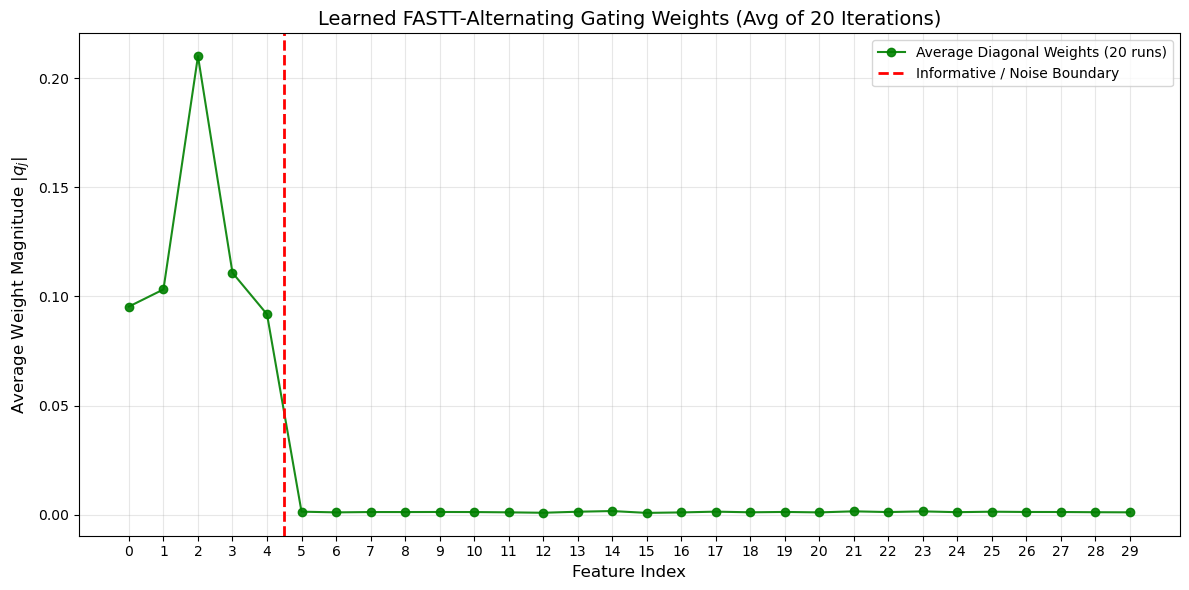

In [6]:
num_experiments = 20
all_gating_weights = []

print(f"Running {num_experiments} iterations of the FASTT-Alternating algorithm...")

for i in range(num_experiments):
    # 1. Generate new synthetic data with a different seed
    current_data_params = data_params.copy()
    current_data_params["seed"] = i
    
    # Suppress output during the loop for cleaner output
    import contextlib
    import io
    import sys
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        X_train_i, Y_train_i, X_test_i, Y_test_i, _ = generate_synthetic_data(current_data_params)
        
        base_selector_i = AdaSTTXGBoost(n_estimators=50, learning_rate=0.1, max_depth=4, early_stopping_rounds=10)
        
        model_i = FASTTAlternating(
            base_selector=base_selector_i,
            transform_type="diagonal",
            transform_kwargs={"lambda1": 0.05, "lambda2": 0.01},
            num_iterations=20,
            transform_lr=1e-2,
            transform_steps=200,
            random_state=i # Vary model seed as well
        )
        model_i.fit(X_train_i, Y_train_i)
        
    weights_i = model_i.get_gating_weights()
    all_gating_weights.append(np.abs(weights_i))
    print(f"Iteration {i+1}/{num_experiments} completed.")

# Calculate average weights
avg_gating_weights = np.mean(all_gating_weights, axis=0)

# Plotting the average results
plt.figure(figsize=(12, 6))
plt.plot(avg_gating_weights, marker='o', alpha=0.9, color='green', label=f'Average Diagonal Weights ({num_experiments} runs)')
    
plt.axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='Informative / Noise Boundary')
plt.title(f'Learned FASTT-Alternating Gating Weights (Avg of {num_experiments} Iterations)', fontsize=14)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Average Weight Magnitude $|q_j|$', fontsize=12)
plt.xticks(range(30))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Single-Model Hyperparameter Tuning

To address the concern that a *single* run might drop some informative features due to redundancy or high L1 regularization, we can use **Optuna** to find a hyperparameter configuration that minimizes Word Error Rate (WER) on a validation set. By doing traditional hyperparameter tuning, we hope the best performing model also captures all informative features without ensembling.

Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts
Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3710


Starting Optuna hyperparameter search for 20 trials...


    Trial 0 finished with value: 0.20401090383529663 and parameters: {'lambda1': 0.0014088960330108284, 'lambda2': 0.009604101049882052, 'colsample_bytree': 0.7247269469403772, 'num_iterations': 15, 'transform_lr': 0.005793790148059939}. Best is trial 0 with value: 0.20401090383529663.
Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts
Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3710
    Trial 1 finished with value: 0.03286907821893692 and parameters: {'lambda1': 0.00021496800069572083, 'lambda2': 0.0047847749276966976, 'colsample_bytree': 0.5886641141449503, 'num_iterations': 15, 'transform_lr': 0.001780828990303549}. Best is trial 0 with value: 0.20401090383529663.
Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts
Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3710
    Trial 2 finished with value: 0.02039373479783535 and parameters: {'lambda1': 0.000476151979695233, 'lambda2': 

Best trial margin: 0.9067
Best hyperparameters: {'lambda1': 0.00010590757904997748, 'lambda2': 0.0001379263018407659, 'colsample_bytree': 0.6742786266069385, 'num_iterations': 22, 'transform_lr': 0.002958818628529295}


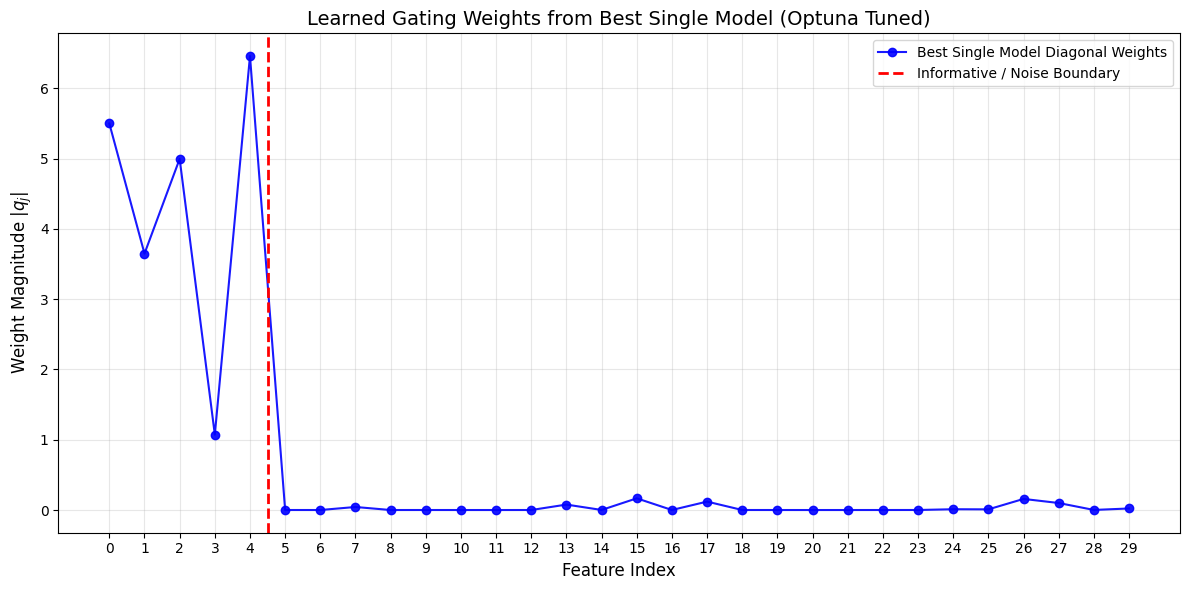

In [32]:
import optuna

def objective(trial):
    # Sample hyperparameters
    lambda1 = trial.suggest_float("lambda1", 1e-4, 1e-1, log=True)
    lambda2 = trial.suggest_float("lambda2", 1e-4, 1e-1, log=True)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    num_iterations = trial.suggest_int("num_iterations", 15, 30)
    transform_lr = trial.suggest_float("transform_lr", 1e-3, 5e-2, log=True)
    
    base_selector = AdaSTTXGBoost(n_estimators=50, learning_rate=0.1, max_depth=4, colsample_bytree=colsample_bytree, early_stopping_rounds=10)
    
    model = FASTTAlternating(
        base_selector=base_selector,
        transform_type="diagonal",
        transform_kwargs={"lambda1": lambda1, "lambda2": lambda2},
        num_iterations=num_iterations,
        transform_lr=transform_lr,
        transform_steps=200,
        random_state=42
    )
    
    current_data_params = data_params.copy()
    current_data_params["seed"] = 42
    
    import contextlib
    import io
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        X_train_opt, Y_train_opt, _, _, _ = generate_synthetic_data(current_data_params)
        model.fit(X_train_opt, Y_train_opt)
        
    weights = np.abs(model.get_gating_weights())
    
    info_weights = weights[:5]
    noise_weights = weights[5:]
    
    # Maximize the margin
    margin = np.min(info_weights) - np.max(noise_weights)
    return margin

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize")
print("Starting Optuna hyperparameter search for 20 trials...")
study.optimize(objective, n_trials=20)

print(f"Best trial margin: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

# Retrain with best params and plot
best_p = study.best_params
best_base = AdaSTTXGBoost(n_estimators=50, learning_rate=0.1, max_depth=4, colsample_bytree=best_p["colsample_bytree"], early_stopping_rounds=10)
best_model = FASTTAlternating(
    base_selector=best_base,
    transform_type="diagonal",
    transform_kwargs={"lambda1": best_p["lambda1"], "lambda2": best_p["lambda2"]},
    num_iterations=best_p["num_iterations"],
    transform_lr=best_p["transform_lr"],
    transform_steps=200,
    random_state=42
)

current_data_params = data_params.copy()
current_data_params["seed"] = 42
X_train_opt, Y_train_opt, _, _, _ = generate_synthetic_data(current_data_params)
import contextlib, io
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    best_model.fit(X_train_opt, Y_train_opt)

best_weights = np.abs(best_model.get_gating_weights())
plt.figure(figsize=(12, 6))
plt.plot(best_weights, marker='o', alpha=0.9, color='blue', label='Best Single Model Diagonal Weights')
plt.axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='Informative / Noise Boundary')
plt.title('Learned Gating Weights from Best Single Model (Optuna Tuned)', fontsize=14)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Weight Magnitude $|q_j|$', fontsize=12)
plt.xticks(range(30))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
